# Evaluation and Error Analysis

## Setup

In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

In [2]:
sns.set_theme(style="ticks", palette="muted", context="paper", font_scale=1.3, rc={
    "lines.linewidth": 2.5,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False
})

DATA_DIR = "data/processed"
ABLATION_DIR = "experiments/ablation"
ENSEMBLE_DIR = "experiments/ensemble_llrd_focal"
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

DEV_INTERNAL_CSV = os.path.join(DATA_DIR, "dev_internal.csv")
TEST_INTERNAL_CSV = os.path.join(DATA_DIR, "test_internal.csv")
DEV_EXTERNAL_CSV = os.path.join(DATA_DIR, "dev_external.csv")
TEST_EXTERNAL_CSV = os.path.join(DATA_DIR, "test_external.csv")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## Classification Metrics

In [3]:
def get_data(csv_path):
    df = pd.read_csv(csv_path)
    texts = df["text"].tolist()
    if "label" in df.columns:
        y_true = df["label"].values
    else:
        # dummy labels for test_external to prevent
        y_true = np.zeros(len(df))
    return texts, y_true

def get_probabilities(model, tokenizer, texts, device, batch_size=8):
    model.eval()
    all_probs = list()

    with torch.inference_mode():
        for i in tqdm(range(0, len(texts), batch_size), desc="Inferencing", leave=False):
            batch_texts = texts[i:i+batch_size]
            batch_inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=256,
                return_tensors="pt"
            ).to(device)

            outputs = model(**batch_inputs)
            probs = torch.sigmoid(outputs.logits).squeeze().cpu().numpy()

            if probs.ndim == 0:
                probs = np.array([probs.item()])
            all_probs.extend(probs)

    return np.array(all_probs)

def find_optimal_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    numerator = 2 * (precisions[:-1] * recalls[:-1])
    denominator = precisions[:-1] + recalls[:-1]
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]

def compute_metrics(y_true, y_probs, threshold, model_name, split_name):
    y_pred = (y_probs >= threshold).astype(int)
    p_class, r_class, f1_class, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    auprc = average_precision_score(y_true, y_probs)

    return {
        "Experiment": model_name,
        "Split": split_name,
        "Threshold": round(threshold, 4),
        "AUPRC": round(auprc, 4),
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "C0 Precision": round(p_class[0], 4),
        "C0 Recall": round(r_class[0], 4),
        "C0 F1": round(f1_class[0], 4),
        "C1 Precision": round(p_class[1], 4),
        "C1 Recall": round(r_class[1], 4),
        "C1 F1": round(f1_class[1], 4),
        "Overall F1": round(f1_macro, 4)
    }

In [4]:
splits = {
    "Validation (Internal)": {"csv": DEV_INTERNAL_CSV},
    "Test (Internal)": {"csv": TEST_INTERNAL_CSV},
    "Dev (External)": {"csv": DEV_EXTERNAL_CSV},
    "Test (External)": {"csv": TEST_EXTERNAL_CSV}
}

all_results = list()
ensemble_data = {split: {"y_true": None, "probs": list(), "preds": list()} for split in splits}

# I. EVALUATE ABLATION MODELS
print("Evaluating Ablation Models...")
for exp_name in sorted(os.listdir(ABLATION_DIR)):
    exp_path = os.path.join(ABLATION_DIR, exp_name)
    config_path = os.path.join(exp_path, "run_config.json")

    if os.path.isdir(exp_path) and os.path.exists(config_path):
        with open(config_path, 'r') as f:
            optimal_tau = json.load(f)["optimization"]["best_threshold"]

        print(f"Loading {exp_name}...")
        tokenizer = AutoTokenizer.from_pretrained(exp_path)
        model = AutoModelForSequenceClassification.from_pretrained(exp_path).to(device)

        for split_name, paths in splits.items():
            if "External" not in split_name:
                texts, y_true = get_data(paths["csv"])
                probs = get_probabilities(model, tokenizer, texts, device)
                metrics = compute_metrics(y_true, probs, optimal_tau, exp_name.replace('_', ' ').title(), split_name)
                all_results.append(metrics)

        del model, tokenizer
        if torch.backends.mps.is_available(): torch.mps.empty_cache()

Evaluating Ablation Models...
Loading 1_roberta...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Loading 2_roberta_llrd...


...

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Loading 4_roberta_llrd_focal...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

In [5]:
# II. EXTRACT ENSEMBLE PROBABILITIES
print("Processing the Ensemble...")
for exp_name in sorted(os.listdir(ENSEMBLE_DIR)):
    exp_path = os.path.join(ENSEMBLE_DIR, exp_name)
    config_path = os.path.join(exp_path, "run_config.json")

    if os.path.isdir(exp_path) and os.path.exists(config_path):
        with open(config_path, 'r') as f:
            indiv_tau = json.load(f)["optimization"]["best_threshold"]

        print(f"Processing {exp_name}...")
        tokenizer = AutoTokenizer.from_pretrained(exp_path)
        model = AutoModelForSequenceClassification.from_pretrained(exp_path).to(device)

        for split_name, paths in splits.items():
            texts, y_true = get_data(paths["csv"])
            probs = get_probabilities(model, tokenizer, texts, device)

            if ensemble_data[split_name]["y_true"] is None:
                ensemble_data[split_name]["y_true"] = y_true

            ensemble_data[split_name]["probs"].append(probs)
            ensemble_data[split_name]["preds"].append((probs >= indiv_tau).astype(int))

        del model, tokenizer
        if torch.backends.mps.is_available(): torch.mps.empty_cache()

Processing the Ensemble...
Processing run1...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/262 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/262 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/479 [00:00<?, ?it/s]

In [6]:
val_split = "Validation (Internal)"
val_soft_probs = np.mean(ensemble_data[val_split]["probs"], axis=0)
optimal_soft_tau = find_optimal_threshold(ensemble_data[val_split]["y_true"], val_soft_probs)
print(f"Optimal ensemble threshold calibrated to: {optimal_soft_tau:.4f}")

soft_results = list()
hard_results = list()
for split_name in ["Validation (Internal)", "Test (Internal)"]:
    y_true = ensemble_data[split_name]["y_true"]
    soft_probs = np.mean(ensemble_data[split_name]["probs"], axis=0)
    soft_metrics = compute_metrics(y_true, soft_probs, optimal_soft_tau, "Ensemble (Soft Voting)", split_name)
    soft_results.append(soft_metrics)

all_results.extend(soft_results)

Optimal ensemble threshold calibrated to: 0.4900


In [7]:
results_df = pd.DataFrame(all_results)
results_df.set_index(["Experiment", "Split"], inplace=True)
display(results_df)

Threshold   AUPRC  Accuracy  \
Experiment             Split                                                
1 Roberta              Validation (Internal)     0.1037  0.6931    0.9263   
                       Test (Internal)           0.1037  0.6147    0.9187   
2 Roberta Llrd         Validation (Internal)     0.0197  0.6791    0.9215   
                       Test (Internal)           0.0197  0.6045    0.9167   
3 Roberta Focal        Validation (Internal)     0.4797  0.6960    0.9445   
                       Test (Internal)           0.4797  0.6504    0.9321   
4 Roberta Llrd Focal   Validation (Internal)     0.5898  0.6742    0.9301   
                       Test (Internal)           0.5898  0.6221    0.9330   
Ensemble (Soft Voting) Validation (Internal)     0.4900  0.7190    0.9416   
                       Test (Internal)           0.4900  0.6704    0.9301   

                                              C0 Precision  C0 Recall   C0 F1  \
Experiment             Split                                                    
1 Roberta              Validation (Internal)        0.9667     0.9513  0.9589   
                       Test (Internal)              0.9654     0.9440  0.9546   
2 Roberta Llrd         Validation (Internal)        0.9695     0.9429  0.9560   
                       Test (Internal)              0.9684     0.9387  0.9533   
3 Roberta Focal        Validation (Internal)        0.9521     0.9884  0.9699   
                       Test (Internal)              0.9451     0.9820  0.9632   
4 Roberta Llrd Focal   Validation (Internal)        0.9609     0.9619  0.9614   
                       Test (Internal)              0.9630     0.9630  0.9630   
Ensemble (Soft Voting) Validation (Internal)        0.9682     0.9672  0.9677   
                       Test (Internal)              0.9668     0.9556  0.9612   

                                              C1 Precision  C1 Recall   C1 F1  \
Experiment             Split                                                    
1 Roberta              Validation (Internal)        0.6000     0.6900  0.6419   
                       Test (Internal)              0.5583     0.6768  0.6119   
2 Roberta Llrd         Validation (Internal)        0.5714     0.7200  0.6372   
                       Test (Internal)              0.5469     0.7071  0.6167   
3 Roberta Focal        Validation (Internal)        0.8281     0.5300  0.6463   
                       Test (Internal)              0.7258     0.4545  0.5590   
4 Roberta Llrd Focal   Validation (Internal)        0.6364     0.6300  0.6332   
                       Test (Internal)              0.6465     0.6465  0.6465   
Ensemble (Soft Voting) Validation (Internal)        0.6931     0.7000  0.6965   
                       Test (Internal)              0.6182     0.6869  0.6507   

                                              Overall F1  
Experiment             Split                              
1 Roberta              Validation (Internal)      0.8004  
                       Test (Internal)            0.7832  
2 Roberta Llrd         Validation (Internal)      0.7966  
                       Test (Internal)            0.7850  
3 Roberta Focal        Validation (Internal)      0.8081  
                       Test (Internal)            0.7611  
4 Roberta Llrd Focal   Validation (Internal)      0.7973  
                       Test (Internal)            0.8047  
Ensemble (Soft Voting) Validation (Internal)      0.8321  
                       Test (Internal)            0.8060

## Saving predictions to disk

In [8]:
ensemble_dev_ext_probs = np.mean(ensemble_data["Dev (External)"]["probs"], axis=0)
ensemble_dev_ext_preds = (ensemble_dev_ext_probs >= optimal_soft_tau).astype(int)

ensemble_test_ext_probs = np.mean(ensemble_data["Test (External)"]["probs"], axis=0)
ensemble_test_ext_preds = (ensemble_test_ext_probs >= optimal_soft_tau).astype(int)

dev_txt_path = os.path.join('.', "dev.txt")
test_txt_path = os.path.join('.', "test.txt")

with open(dev_txt_path, "w") as f:
    for pred in ensemble_dev_ext_preds:
        f.write(f"{pred}\n")

with open(test_txt_path, "w") as f:
    for pred in ensemble_test_ext_preds:
        f.write(f"{pred}\n")

print(f"Official submission files generated in the root directory.")
print(f"    - dev.txt lines (Dev External):     {len(ensemble_dev_ext_preds)}")
print(f"    - test.txt lines (Test External):   {len(ensemble_test_ext_preds)}")

Official submission files generated in the root directory.
    - dev.txt lines (Dev External):     2094
    - test.txt lines (Test External):   3832


## Precision-Recall Curves and Confusion Matrices

In [9]:
# Locate baseline directory dynamically
baseline_folder = [d for d in os.listdir(ABLATION_DIR) if "1" in d and "roberta" in d.lower()][0]
baseline_dir = os.path.join(ABLATION_DIR, baseline_folder)

with open(os.path.join(baseline_dir, "run_config.json"), 'r') as f:
    baseline_test_tau = json.load(f)["optimization"]["best_threshold"]

baseline_tokenizer = AutoTokenizer.from_pretrained(baseline_dir)
baseline_model = AutoModelForSequenceClassification.from_pretrained(baseline_dir).to(device)

test_texts, test_y_true = get_data(splits["Test (Internal)"]["csv"])
baseline_test_probs = get_probabilities(baseline_model, baseline_tokenizer, test_texts, device)
baseline_test_preds = (baseline_test_probs >= baseline_test_tau).astype(int)

# Extract final Ensemble probabilities for the Internal Test Set
ensemble_test_probs = np.mean(ensemble_data['Test (Internal)']['probs'], axis=0)
ensemble_test_preds = (ensemble_test_probs >= optimal_soft_tau).astype(int)

del baseline_model, baseline_tokenizer
if torch.backends.mps.is_available(): torch.mps.empty_cache()
print("Baseline loaded successfully.")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Inferencing:   0%|          | 0/131 [00:00<?, ?it/s]

Baseline loaded successfully.


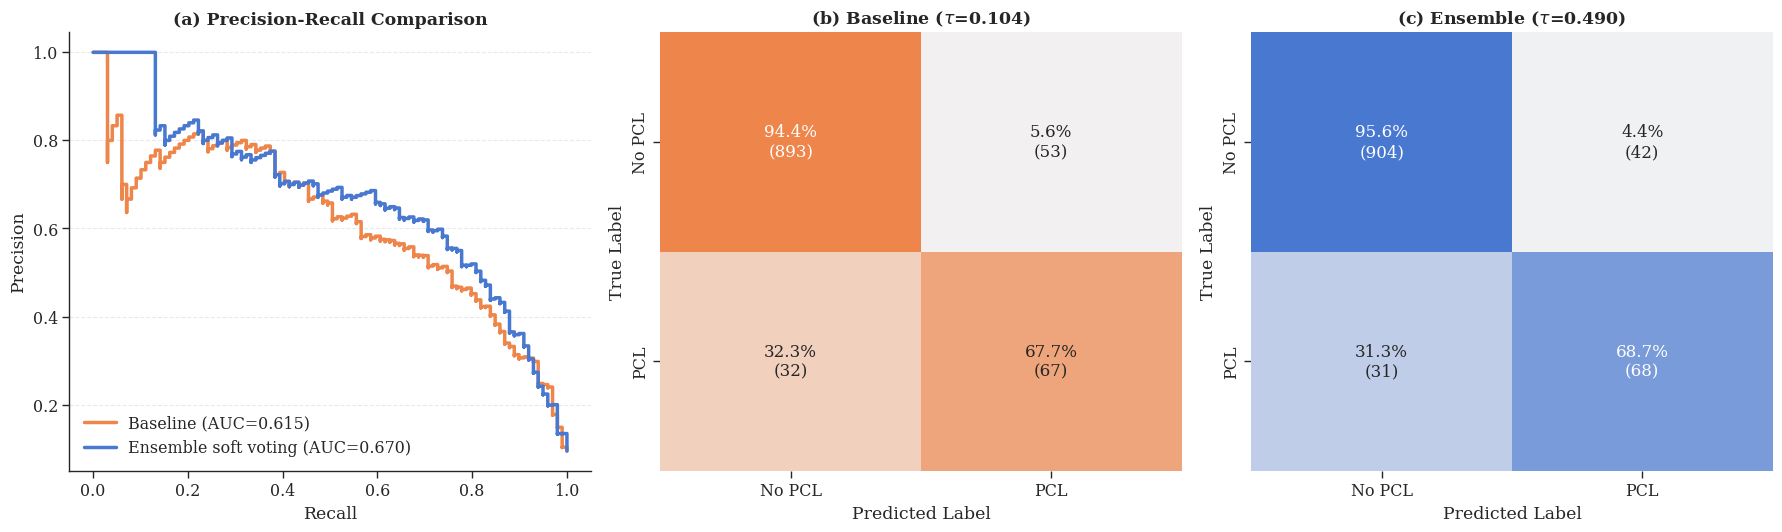

In [10]:
colors = sns.color_palette("muted")
model_colors = {"Baseline": colors[1], "Ensemble": colors[0]}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (1) PR curve
base_prec, base_rec, _ = precision_recall_curve(test_y_true, baseline_test_probs)
base_auprc = average_precision_score(test_y_true, baseline_test_probs)

ens_prec, ens_rec, _ = precision_recall_curve(test_y_true, ensemble_test_probs)
ens_auprc = average_precision_score(test_y_true, ensemble_test_probs)

axes[0].step(base_rec, base_prec, color=model_colors["Baseline"], where="post", label=f"Baseline (AUC={base_auprc:.3f})")
axes[0].step(ens_rec, ens_prec, color=model_colors["Ensemble"], where="post", label=f"Ensemble soft voting (AUC={ens_auprc:.3f})")

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("(a) Precision-Recall Comparison", loc="center", fontweight="bold")
axes[0].legend(frameon=False, loc="lower left")
axes[0].grid(axis='y', linestyle="--", alpha=0.4)

# (2 & 3) CMs
def plot_styled_cm(y_true, y_pred, ax, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    labels = [f"{val:.1%}\n({count})" for val, count in zip(cm_norm.flatten(), cm.flatten())]
    labels = np.asarray(labels).reshape(2, 2)
    sns.heatmap(
        cm_norm,
        annot=labels,
        fmt='',
        cmap=cmap,
        ax=ax,
        cbar=False,
        annot_kws={"size": 12},
        xticklabels=["No PCL", "PCL"],
        yticklabels=["No PCL", "PCL"]
    )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plot_styled_cm(
    test_y_true, baseline_test_preds, axes[1],
    fr"(b) Baseline ($\tau$={baseline_test_tau:.3f})",
    sns.light_palette(model_colors["Baseline"], as_cmap=True)
)

plot_styled_cm(
    test_y_true, ensemble_test_preds, axes[2],
    rf"(c) Ensemble ($\tau$={optimal_soft_tau:.3f})",
    sns.light_palette(model_colors["Ensemble"], as_cmap=True)
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_evaluation_metrics.pdf"), bbox_inches="tight", dpi=300)
plt.show()

## Error Analysis

In [11]:
error_df = pd.DataFrame({
    "text": test_texts,
    "y_true": test_y_true,
    "y_baseline": baseline_test_preds,
    "prob_baseline": baseline_test_probs,
    "y_ensemble": ensemble_test_preds,
    "prob_ensemble": ensemble_test_probs
})

rescues = error_df[(error_df["y_true"] == 1) & (error_df["y_baseline"] == 0) & (error_df["y_ensemble"] == 1)]
overcorrections = error_df[(error_df["y_true"] == 1) & (error_df["y_baseline"] == 1) & (error_df["y_ensemble"] == 0)]
false_positives = error_df[(error_df["y_true"] == 0) & (error_df["y_baseline"] == 1) & (error_df["y_ensemble"] == 1)]

def print_samples(df, category_name, num_samples=30):
    print(f"\n{'='*80}")
    print(f"CATEGORY: {category_name} (Total in category: {len(df)})")
    print(f"{'='*80}")

    sorted_df = df.sort_values(by="prob_ensemble", ascending=False)
    for i, row in sorted_df.head(num_samples).iterrows():
        print(f"Ensemble Pr: {row['prob_ensemble']:.3f} | Baseline Pr: {row['prob_baseline']:.3f} | Text:")
        print(f"{row['text']}")
        print("-" * 80)

print_samples(rescues, "The Correction")
print_samples(overcorrections, "The Overcorrection")
print_samples(false_positives, "Shared Hallucinations")


CATEGORY: The Correction (Total in category: 6)
Ensemble Pr: 0.906 | Baseline Pr: 0.042 | Text:
[KEYWORD] in-need [COUNTRY] tz [SEP] The ten wheelchairs were sought for children identified by the host, Salvation Army to enable them to become mobile, the convener noted. Baps Charity would go anywhere to donate provided there are found people in need of the donations without any discrimination relating to religion, colour, origins or tribe, he stated.
--------------------------------------------------------------------------------
Ensemble Pr: 0.900 | Baseline Pr: 0.086 | Text:
[KEYWORD] migrant [COUNTRY] bd [SEP] At Davos, the World Economic Forum dedicated this year to cultivate "responsive "and "responsible "leadership in a world largely lacking both. This mission obviously refers to domestic-national leaders, who must now serve as the bastion of bringing a torn and submerging planet from disaster, whether caused by over-adrenalised presidents and prime ministers, or environmental de